# Практичне заняття № 1 — класифікація засобами scikit-learn

Датасет — **Ethereum Fraud Detection**: 9 841 акаунт мережі Ethereum,
розмічений за ознакою шахрайства. Цільова змінна `FLAG`:

* `0` — легітимний акаунт,
* `1` — акаунт, причетний до шахрайських схем (скам, Ponzi, фішинг).

Ознаки описують поведінку акаунта в мережі: інтенсивність транзакцій, суми
надісланого й отриманого ETH, кількість унікальних контрагентів та окремо —
активність із токенами стандарту ERC20.

Датасет обрано через відповідність напряму підготовки й особистому інтересу
до блокчейну: це криміналістика розподіленого реєстру, де ознаки рахуються
безпосередньо з графа транзакцій.

## 0. Підготовка середовища

Клітинка нижче створює теки `data/` та `assets/` і, якщо датасета ще немає,
завантажує його з Kaggle через `kagglehub`. У Colab вона також доставляє
відсутні пакети, тож ноутбук можна виконати там без жодних ручних кроків.

In [1]:
import importlib.util
import os
import shutil
import subprocess
import sys
from pathlib import Path


def _in_colab():
    if "google.colab" in sys.modules:
        return True
    try:
        return importlib.util.find_spec("google.colab") is not None
    except (ImportError, ValueError):
        # find_spec імпортує батьківський пакет; без нього — це не Colab
        return False


IN_COLAB = _in_colab()

DATA = Path("data")
ASSETS = Path("assets")
DATA.mkdir(exist_ok=True)
ASSETS.mkdir(exist_ok=True)

DATASET = DATA / "ethereum-fraud.csv"
KAGGLE_SLUG = "vagifa/ethereum-frauddetection-dataset"
EXPECTED_COLS = 51


def _check_dataset():
    """Переконатися, що завантажили саме той набір.

    Kaggle може оновити версію датасета; краще впасти тут, ніж мовчки
    отримати інші числа, ніж у звіті.
    """
    import pandas as pd
    n = pd.read_csv(DATASET, nrows=1).shape[1]
    if n != EXPECTED_COLS:
        raise ValueError(f"очікували {EXPECTED_COLS} колонок, отримали {n}")


def _ensure_packages():
    """У Colab усе потрібне вже є; доставляємо лише те, чого бракує."""
    missing = [p for p in ("pandas", "sklearn", "matplotlib", "seaborn")
               if importlib.util.find_spec(p) is None]
    if missing:
        names = {"sklearn": "scikit-learn"}
        pkgs = [names.get(m, m) for m in missing]
        print("встановлюю:", ", ".join(pkgs))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=True)


def _ensure_dataset():
    if DATASET.exists():
        print(f"датасет на місці: {DATASET} ({DATASET.stat().st_size / 1e6:.1f} МБ)")
        return
    if importlib.util.find_spec("kagglehub"):
        try:
            import kagglehub
            print(f"завантажую {KAGGLE_SLUG} через kagglehub...")
            root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
            csv = max(root.rglob("*.csv"), key=lambda f: f.stat().st_size)
            shutil.copy(csv, DATASET)
            _check_dataset()
            return
        except Exception as exc:
            print(f"kagglehub не спрацював ({exc}); пробую інший шлях")
    if IN_COLAB:
        print("Завантажте transaction_dataset.csv вручну (кнопка нижче).")
        from google.colab import files
        for name, blob in files.upload().items():
            DATASET.write_bytes(blob)
            print(f"отримано {name}")
        return
    raise FileNotFoundError(
        f"{DATASET} не знайдено. Візьміть датасет за адресою "
        f"https://www.kaggle.com/datasets/{KAGGLE_SLUG} і покладіть у {DATA}/."
    )


if IN_COLAB:
    _ensure_packages()
_ensure_dataset()

датасет на місці: data/ethereum-fraud.csv (2.9 МБ)


In [2]:
import textwrap
import time

import matplotlib
# Agg потрібен лише коли код запускають як звичайний скрипт: без ядра
# Jupyter matplotlib шукав би GUI-бекенд. У ноутбуці (локально чи в Colab)
# лишаємо інлайн-бекенд, щоб рисунки потрапляли в саму .ipynb.
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                     cross_val_score, train_test_split)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
TEST_SIZE = 0.25

np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.bbox"] = "tight"


def save(fig, name):
    """Зберегти рисунок в assets/ і показати його в ноутбуці."""
    fig.savefig(ASSETS / name)
    try:
        from IPython.display import display
        display(fig)          # інакше рисунка не буде ні в .ipynb, ні в Colab
    except ImportError:
        pass
    plt.close(fig)
    print("збережено", ASSETS / name)

## 1. Завантаження та первинний аналіз даних

In [3]:
df = pd.read_csv(DATASET)
# у частини заголовків є провідні пробіли (" Total ERC20 tnxs") — прибираємо,
# інакше до колонок довелося б звертатися з пробілом
df.columns = [c.strip() for c in df.columns]

print(f"Розмір датасета: {df.shape[0]} рядків × {df.shape[1]} колонок")
print(f"\nНазви колонок ({len(df.columns)}):")
for i, c in enumerate(df.columns, 1):
    print(f"  {i:>2}. {c}")

Розмір датасета: 9841 рядків × 51 колонок

Назви колонок (51):
   1. Unnamed: 0
   2. Index
   3. Address
   4. FLAG
   5. Avg min between sent tnx
   6. Avg min between received tnx
   7. Time Diff between first and last (Mins)
   8. Sent tnx
   9. Received Tnx
  10. Number of Created Contracts
  11. Unique Received From Addresses
  12. Unique Sent To Addresses
  13. min value received
  14. max value received
  15. avg val received
  16. min val sent
  17. max val sent
  18. avg val sent
  19. min value sent to contract
  20. max val sent to contract
  21. avg value sent to contract
  22. total transactions (including tnx to create contract
  23. total Ether sent
  24. total ether received
  25. total ether sent contracts
  26. total ether balance
  27. Total ERC20 tnxs
  28. ERC20 total Ether received
  29. ERC20 total ether sent
  30. ERC20 total Ether sent contract
  31. ERC20 uniq sent addr
  32. ERC20 uniq rec addr
  33. ERC20 uniq sent addr.1
  34. ERC20 uniq rec contract addr


In [4]:
TARGET = "FLAG"
features_all = [c for c in df.columns if c != TARGET]

print(f"Цільова змінна (target): {TARGET}")
print(f"Ознак у сирому вигляді: {len(features_all)}")

print("\nТипи даних:")
print(df.dtypes.value_counts().to_string())
print("\nЧислових колонок:", df.select_dtypes(include=[np.number]).shape[1])
print("Рядкових колонок:", df.select_dtypes(exclude=[np.number]).shape[1])

Цільова змінна (target): FLAG
Ознак у сирому вигляді: 50

Типи даних:
float64    39
int64       9
str         3

Числових колонок: 48
Рядкових колонок: 3


Розподіл об'єктів за класами:
      кількість  частка
FLAG                   
0          7662  0.7786
1          2179  0.2214

Базова лінія (частка найбільшого класу): 0.7786


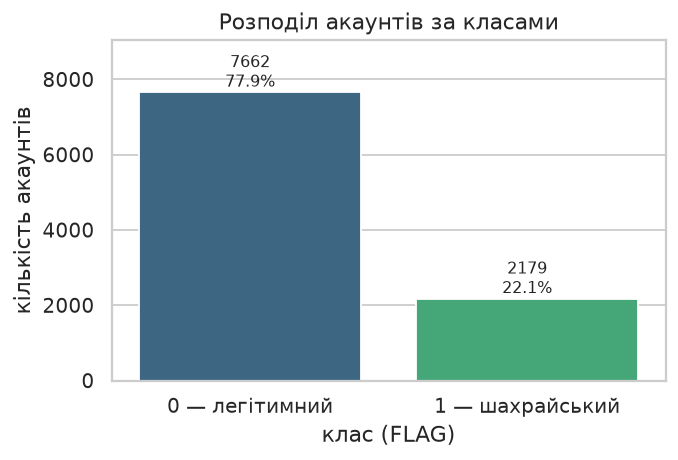

збережено assets/01-class-distribution.png


In [5]:
counts = df[TARGET].value_counts().sort_index()
shares = df[TARGET].value_counts(normalize=True).sort_index()
names = {0: "0 — легітимний", 1: "1 — шахрайський"}
print("Розподіл об'єктів за класами:")
print(pd.DataFrame({"кількість": counts, "частка": shares.round(4)}).to_string())
print(f"\nБазова лінія (частка найбільшого класу): {shares.max():.4f}")

fig, ax = plt.subplots(figsize=(5.5, 3.4))
sns.barplot(x=[names[i] for i in counts.index], y=counts.values,
            hue=[names[i] for i in counts.index], legend=False,
            palette="viridis", ax=ax)
ax.set_xlabel("клас (FLAG)")
ax.set_ylabel("кількість акаунтів")
ax.set_title("Розподіл акаунтів за класами")
for i, v in enumerate(counts.values):
    ax.text(i, v, f"{v}\n{shares.iloc[i]:.1%}", ha="center", va="bottom", fontsize=9)
ax.set_ylim(0, counts.max() * 1.18)
save(fig, "01-class-distribution.png")

Класи незбалансовані у співвідношенні приблизно 1:3.5 (22.1 % шахрайських).
Це помірний дисбаланс: спеціальні засоби (oversampling, ваги класів) не
обов'язкові, але **accuracy як метрика вже ненадійна** — модель, що завжди
відповідає «легітимний», отримає 0.7786. Тому основною метрикою далі
використовується **F1-macro**, який усереднює F1 по обох класах і не дає
сховати провал на меншому класі.

## 2. Попередня обробка даних

### 2.1. Службові колонки: перевірка на витік мітки

Перші три колонки — `Unnamed: 0`, `Index`, `Address` — виглядають як
технічні ідентифікатори. Перед тим як просто їх викинути, варто перевірити,
чи не «протікає» через них мітка: якщо датасет збирали, склеївши окремо
зібрані шахрайські й легітимні акаунти, порядковий номер може однозначно
видавати клас.

In [6]:
ID_COLS = ["Unnamed: 0", "Address", "Index"]

print("Діапазон 'Unnamed: 0' за класами:")
print(df.groupby(TARGET)["Unnamed: 0"].agg(["min", "max"]).to_string())

print("\nДіапазон 'Index' за класами:")
print(df.groupby(TARGET)["Index"].agg(["min", "max", "count"]).to_string())

over = df["Index"] > df.loc[df[TARGET] == 1, "Index"].max()
print(f"\nАкаунтів з Index > {df.loc[df[TARGET] == 1, 'Index'].max()}: {over.sum()}")
print(f"  з них шахрайських: {df.loc[over, TARGET].sum()} "
      f"(частка {df.loc[over, TARGET].mean():.4f})")

print(f"\nУнікальних значень Address: {df['Address'].nunique()} із {len(df)}")

Діапазон 'Unnamed: 0' за класами:
       min   max
FLAG            
0        0  7661
1     7662  9840

Діапазон 'Index' за класами:
      min   max  count
FLAG                  
0       1  4729   7662
1       1  2179   2179

Акаунтів з Index > 2179: 3304
  з них шахрайських: 0 (частка 0.0000)

Унікальних значень Address: 9816 із 9841


Витік підтверджено, і він грубий:

* `Unnamed: 0` — це просто номер рядка, а рядки **відсортовані за класом**:
  легітимні акаунти займають позиції 0…7661, шахрайські — 7662…9840. Одне
  порівняння `Unnamed: 0 >= 7662` дає стопроцентну класифікацію.
* `Index` нумерується **всередині кожного класу окремо**: у шахрайських він
  іде від 1 до 2179, у легітимних — від 1 до 4729. Тому правило
  «`Index` > 2179 → легітимний» безпомилково розмічає 3 304 акаунти.
* `Address` — хеш гаманця, майже унікальний (9 816 значень на 9 841 рядок).
  Як ознака він марний, а дерево на ньому просто запам'ятає вибірку.

Переконаємося кількісно, наскільки сильний цей витік.

In [7]:
leak_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
leak_X = df[["Unnamed: 0", "Index"]]
leak_cv = cross_val_score(leak_tree, leak_X, df[TARGET],
                          cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                          scoring="f1_macro")
print(f"Дерево ЛИШЕ на службових колонках: F1-macro = {leak_cv.mean():.4f}")
print("Тобто без жодної поведінкової ознаки модель була б майже ідеальною —")
print("саме тому ці колонки треба прибрати, а не лишати «про всяк випадок».")

df = df.drop(columns=ID_COLS)
print(f"\nПрибрано {len(ID_COLS)} службових колонок; лишилося {df.shape[1]}")

Дерево ЛИШЕ на службових колонках: F1-macro = 0.9997
Тобто без жодної поведінкової ознаки модель була б майже ідеальною —
саме тому ці колонки треба прибрати, а не лишати «про всяк випадок».

Прибрано 3 службових колонок; лишилося 48


### 2.2. Константні колонки

In [8]:
numeric_all = df.drop(columns=[TARGET]).select_dtypes(include=[np.number])
const_cols = [c for c in numeric_all.columns if numeric_all[c].nunique(dropna=True) <= 1]
print(f"Колонок з одним-єдиним значенням: {len(const_cols)}")
for c in const_cols:
    print(f"  {c} = {numeric_all[c].dropna().unique()[:1]}")

df = df.drop(columns=const_cols)
print(f"\nПісля видалення константних лишилося {df.shape[1]} колонок")

Колонок з одним-єдиним значенням: 7
  ERC20 avg time between sent tnx = [0.]
  ERC20 avg time between rec tnx = [0.]
  ERC20 avg time between rec 2 tnx = [0.]
  ERC20 avg time between contract tnx = [0.]
  ERC20 min val sent contract = [0.]
  ERC20 max val sent contract = [0.]
  ERC20 avg val sent contract = [0.]

Після видалення константних лишилося 41 колонок


Сім ERC20-колонок містять одне й те саме значення для всіх рядків. Нульова
дисперсія означає нульову інформативність: розділити за ними неможливо, а
`StandardScaler` на них дав би ділення на нуль.

### 2.3. Пропущені значення

In [9]:
na = df.isna().sum()
na = na[na > 0].sort_values(ascending=False)
print(f"Колонок із пропусками: {len(na)} із {df.shape[1]}")
print(na.to_string())

Колонок із пропусками: 18 із 41
ERC20 most sent token type         2697
ERC20_most_rec_token_type           871
ERC20 total Ether received          829
Total ERC20 tnxs                    829
ERC20 total ether sent              829
ERC20 total Ether sent contract     829
ERC20 uniq sent addr.1              829
ERC20 uniq rec contract addr        829
ERC20 uniq sent addr                829
ERC20 uniq rec addr                 829
ERC20 max val rec                   829
ERC20 min val rec                   829
ERC20 avg val rec                   829
ERC20 min val sent                  829
ERC20 avg val sent                  829
ERC20 max val sent                  829
ERC20 uniq rec token name           829
ERC20 uniq sent token name          829


Пропуски утворюють рівно три групи, і кожна має власну природу. Перевіримо
найбільшу — 829 рядків, де відсутні **всі** числові ERC20-ознаки одразу.

In [10]:
miss_erc = df["Total ERC20 tnxs"].isna()
print(f"Рядків без числових ERC20-даних: {miss_erc.sum()}")
print("\nРозподіл класів залежно від наявності ERC20-даних:")
print(pd.crosstab(miss_erc.map({False: "ERC20 є", True: "ERC20 немає"}),
                  df[TARGET], normalize="index").round(4).to_string())

tp = (miss_erc & (df[TARGET] == 1)).sum()
fp = (miss_erc & (df[TARGET] == 0)).sum()
print(f"\nПравило «немає ERC20-даних → шахрай»: "
      f"precision = {tp / (tp + fp):.4f}, recall = {tp / (df[TARGET] == 1).sum():.4f}")

zero = (df["Total ERC20 tnxs"] == 0)
print(f"\nДля порівняння, рядків із Total ERC20 tnxs == 0: {zero.sum()}, "
      f"серед них шахраїв: {df.loc[zero, TARGET].mean():.4f}")

Рядків без числових ERC20-даних: 829

Розподіл класів залежно від наявності ERC20-даних:
FLAG                   0       1
Total ERC20 tnxs                
ERC20 немає       0.0000  1.0000
ERC20 є           0.8502  0.1498

Правило «немає ERC20-даних → шахрай»: precision = 1.0000, recall = 0.3804

Для порівняння, рядків із Total ERC20 tnxs == 0: 4399, серед них шахраїв: 0.0000


Результат показовий: **усі 829 акаунтів без ERC20-даних — шахрайські**
(precision = 1.0 при recall = 0.38). При цьому «немає даних» і «нуль
ERC20-транзакцій» — різні речі: є ще 4 399 акаунтів із явним нулем, і серед
них шахраїв немає зовсім.

Отже, `NaN` тут — не «нуль активності», а артефакт складання датасета: для
частини шахрайських акаунтів ERC20-статистику просто не зібрали. Сама
**відсутність** значення виявляється сильнішим предиктором, ніж будь-яке
значення.

Рішення: заповнюємо пропуски медіаною **всередині pipeline** і свідомо
**не** додаємо окремий прапорець «значення було відсутнє». Такий прапорець
підняв би метрики, але вчив би модель артефакту збору даних, а не поведінки
акаунта. Наскільки це впливає на результат — виміряємо в підрозділі 6.3.

### 2.4. Категоріальні ознаки

In [11]:
CAT_COLS = df.select_dtypes(exclude=[np.number]).columns.tolist()
print(f"Категоріальні колонки ({len(CAT_COLS)}):")
for c in CAT_COLS:
    print(f"\n  {c}: {df[c].nunique()} унікальних, {df[c].isna().sum()} пропусків")
    print("   найчастіші:", dict(df[c].value_counts().head(4)))

Категоріальні колонки (2):

  ERC20 most sent token type: 304 унікальних, 2697 пропусків
   найчастіші: {'0': np.int64(4399), ' ': np.int64(1191), 'EOS': np.int64(138), 'OmiseGO': np.int64(137)}

  ERC20_most_rec_token_type: 466 унікальних, 871 пропусків
   найчастіші: {'0': np.int64(4399), 'OmiseGO': np.int64(873), 'Blockwell say NOTSAFU': np.int64(779), 'DATAcoin': np.int64(358)}


Обидві колонки — назви найпопулярнішого токена ERC20. Тут два ускладнення:

1. **Висока потужність** (304 і 466 унікальних назв). Прямий one-hot додав
   би 770 стовпців на 9 841 рядок — більше ознак, ніж спостережень на
   категорію, що гарантує перенавчання.
2. **Приховані плейсхолдери**: найчастіші «назви» — це `'0'` (4 399 разів,
   акаунти без ERC20-активності) і `' '` — звичайний пробіл. Це не токени.

Рішення: `OneHotEncoder` з `max_categories=11`. Він лишає 10 найчастіших
назв, а весь «хвіст» зводить в одну категорію `infrequent`. Важливо, що
порогом керує сам енкодер **усередині pipeline**, тобто список популярних
токенів рахується лише на навчальній частині кожного фолда — інакше вибір
категорій підглядав би в тест.

Порядкове кодування (`OrdinalEncoder`) тут не годиться: назви токенів
номінальні, у них немає природного порядку, а kNN і SVM сприймали б різницю
кодів як відстань.

### 2.5. Викиди

In [12]:
NUM_COLS = df.drop(columns=[TARGET]).select_dtypes(include=[np.number]).columns.tolist()
rows = []
for c in NUM_COLS:
    s = df[c]
    out = ((s - s.mean()).abs() > 3 * s.std()).sum()
    rows.append({"ознака": c, "макс": s.max(), "викидів (3σ)": out,
                 "частка": out / s.notna().sum()})
outl = pd.DataFrame(rows).sort_values("частка", ascending=False)
print("Топ-8 ознак за часткою викидів (правило трьох сигм):")
print(outl.head(8).to_string(index=False, formatters={"частка": "{:.2%}".format}))
print(f"\nЧислових ознак: {len(NUM_COLS)}")

Топ-8 ознак за часткою викидів (правило трьох сигм):
                                              ознака       макс  викидів (3σ) частка
                        Avg min between received tnx  482175.49           192  1.95%
total transactions (including tnx to create contract   19995.00           192  1.95%
                            Avg min between sent tnx  430287.67           186  1.89%
                          ERC20 uniq sent token name     213.00           154  1.71%
                           ERC20 uniq rec token name     737.00           146  1.62%
                        ERC20 uniq rec contract addr     782.00           138  1.53%
             Time Diff between first and last (Mins) 1954860.95           145  1.47%
                                        Received Tnx   10000.00           140  1.42%

Числових ознак: 38


Викиди **не видаляємо**. Правило трьох сигм передбачає нормальний розподіл,
а тут усі грошові ознаки мають важкий правий хвіст: більшість акаунтів
оперує малими сумами, а окремі — тисячами ETH. Це не помилки вимірювання, а
власне та поведінка, яку модель має розпізнавати. Натомість застосовуємо
`StandardScaler` для алгоритмів, чутливих до масштабу.

## 3. Візуалізація та дослідження даних (EDA)

Ознак багато (38 числових), тому для рисунків беремо найінформативніші —
за важливістю у попередньому Random Forest.

Вісім найінформативніших числових ознак:
Time Diff between first and last (Mins)    0.1185
Total ERC20 tnxs                           0.0900
ERC20 uniq rec addr                        0.0776
ERC20 uniq rec contract addr               0.0674
total ether received                       0.0673
ERC20 uniq rec token name                  0.0637
Avg min between received tnx               0.0563
max value received                         0.0414


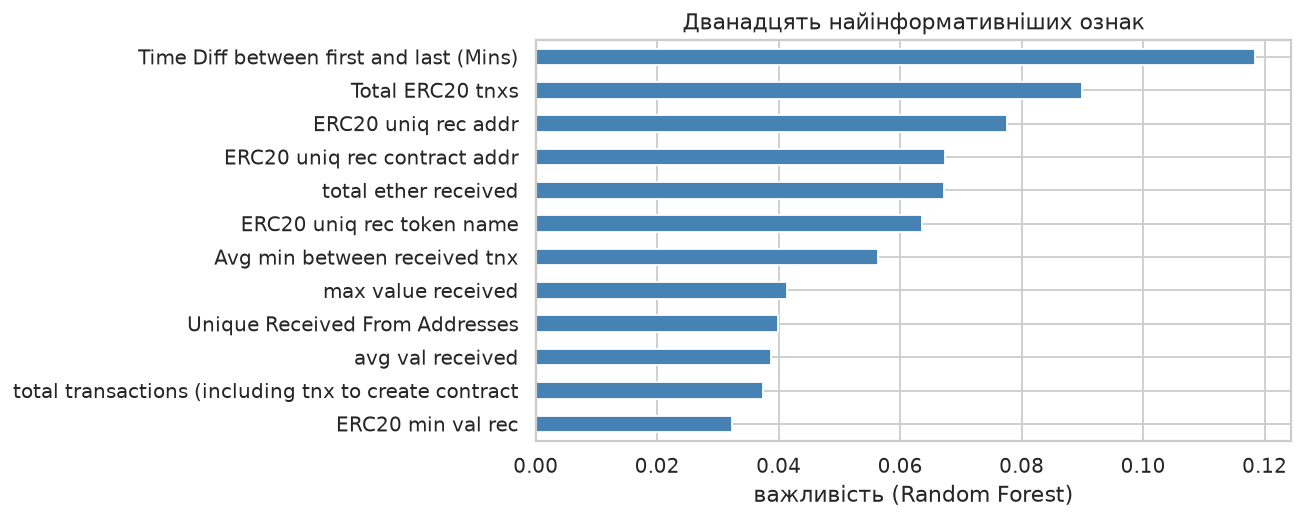

збережено assets/02-feature-importance.png


In [13]:
_imp_pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                      ("m", RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                                   random_state=RANDOM_STATE))])
_imp_pipe.fit(df[NUM_COLS], df[TARGET])
importances = (pd.Series(_imp_pipe.named_steps["m"].feature_importances_, index=NUM_COLS)
               .sort_values(ascending=False))
TOP = importances.head(8).index.tolist()
print("Вісім найінформативніших числових ознак:")
print(importances.head(8).round(4).to_string())

fig, ax = plt.subplots(figsize=(7.5, 4))
importances.head(12)[::-1].plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("важливість (Random Forest)")
ax.set_title("Дванадцять найінформативніших ознак")
save(fig, "02-feature-importance.png")

### 3.1. Heatmap кореляцій

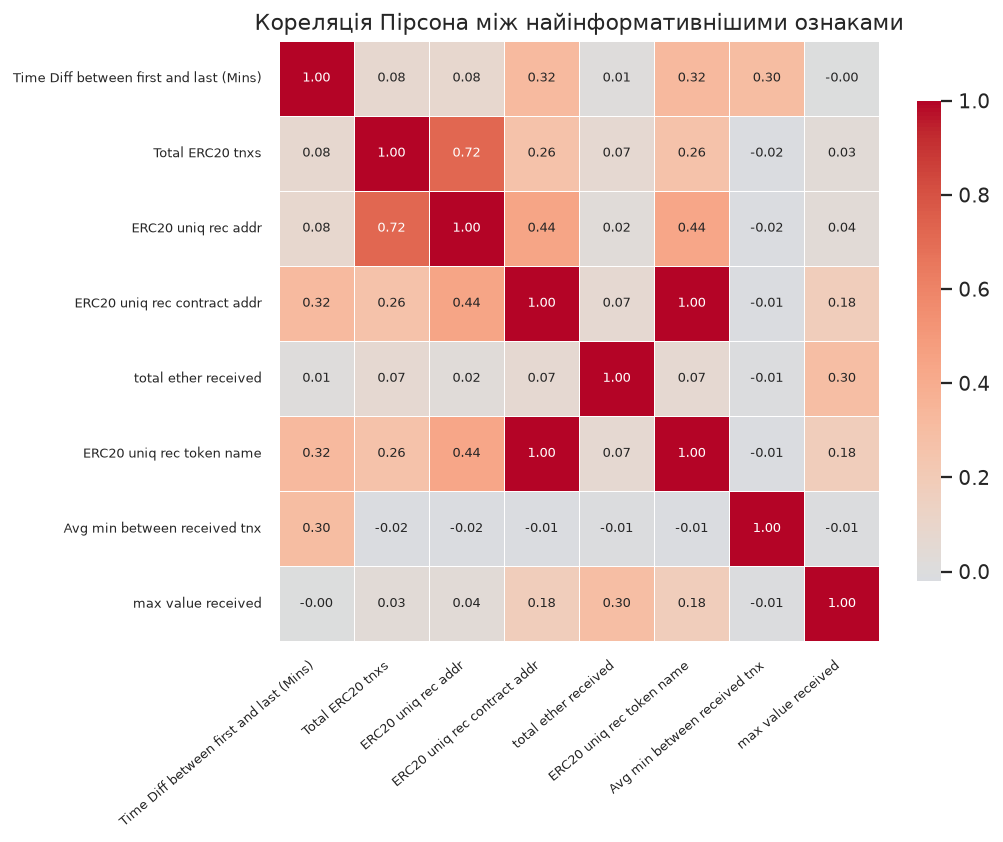

збережено assets/03-correlation-heatmap.png
Найсильніші кореляції серед відібраних ознак:
ERC20 uniq rec token name  ERC20 uniq rec contract addr    1.000
ERC20 uniq rec addr        Total ERC20 tnxs                0.717
                           ERC20 uniq rec contract addr    0.443


In [14]:
corr = df[TOP].corr()
fig, ax = plt.subplots(figsize=(7.5, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .8},
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Кореляція Пірсона між найінформативнішими ознаками")
plt.setp(ax.get_xticklabels(), rotation=40, ha="right", fontsize=7)
plt.setp(ax.get_yticklabels(), fontsize=7)
save(fig, "03-correlation-heatmap.png")

pairs = (corr.where(~np.eye(len(corr), dtype=bool)).abs().unstack()
         .sort_values(ascending=False).head(6))
print("Найсильніші кореляції серед відібраних ознак:")
print(pairs.iloc[::2].round(3).to_string())

### 3.2. Гістограми розподілу ознак

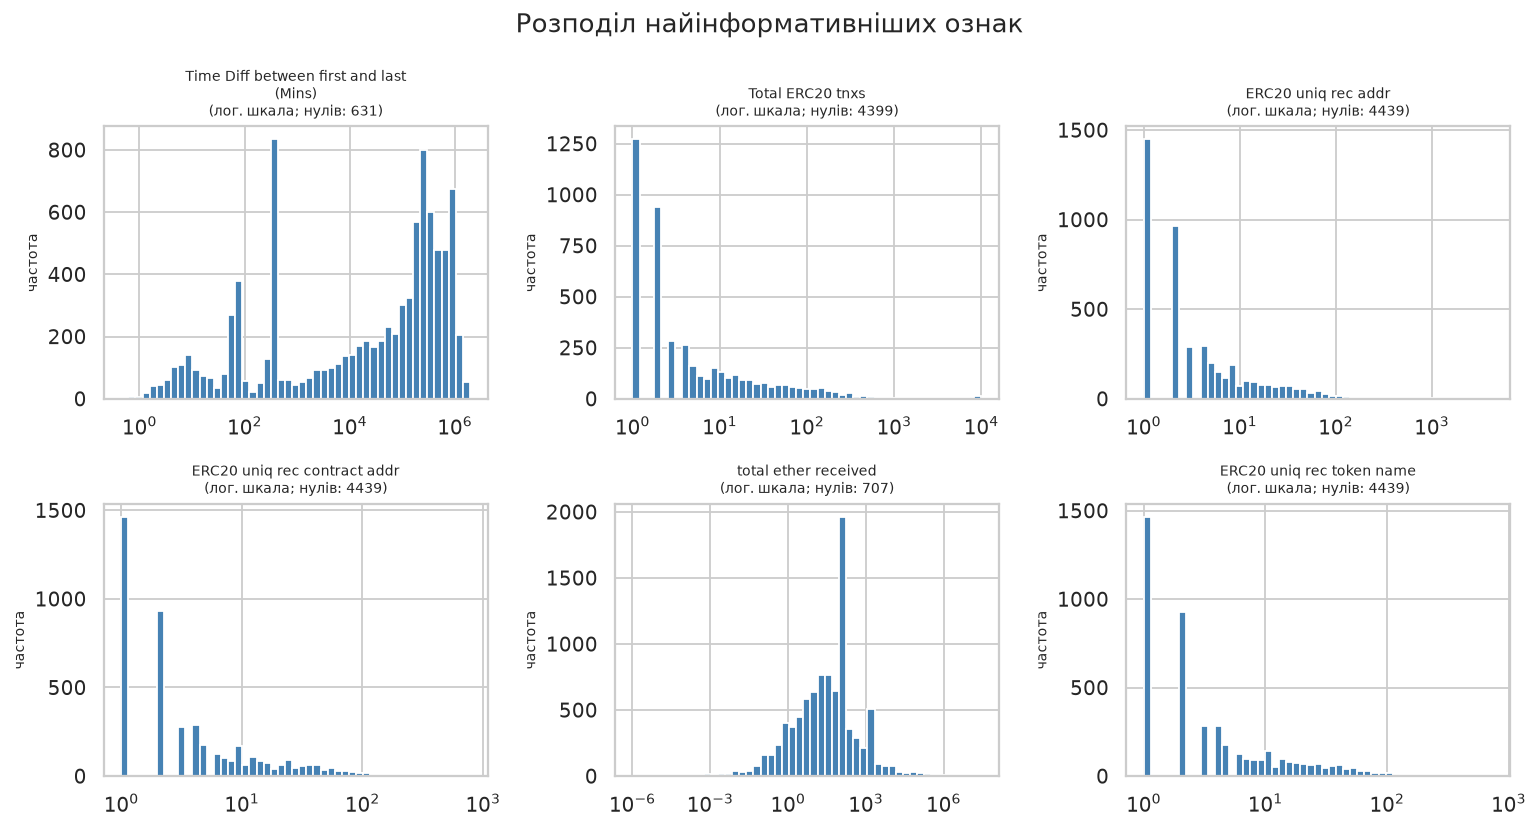

збережено assets/04-histograms.png
Асиметрія (skewness):
Time Diff between first and last (Mins)     1.81
Total ERC20 tnxs                           19.93
ERC20 uniq rec addr                        37.59
ERC20 uniq rec contract addr               16.33
total ether received                       58.80
ERC20 uniq rec token name                  15.54
Avg min between received tnx                6.75
max value received                         46.42


In [15]:
def short(name, width=32):
    """Перенести довгу назву ознаки на кілька рядків замість обрізання."""
    return "\n".join(textwrap.wrap(name, width))


fig, axes = plt.subplots(2, 3, figsize=(12, 6.5))
for ax, c in zip(axes.ravel(), TOP[:6]):
    s = df[c].dropna()
    pos = s[s > 0]
    if len(pos) > 0 and pos.max() / pos.min() > 50:
        # на логарифмічній осі біни теж мають бути логарифмічні: лінійний
        # бін 0…max/50 займав би кілька порядків і малювався одним блоком
        bins = np.logspace(np.log10(pos.min()), np.log10(pos.max()), 50)
        ax.hist(pos, bins=bins, color="steelblue")
        ax.set_xscale("log")
        zeros = (s == 0).sum()
        note = f"лог. шкала; нулів: {zeros}" if zeros else "лог. шкала"
        ax.set_title(f"{short(c)}\n({note})", fontsize=8)
    else:
        ax.hist(s, bins=50, color="steelblue")
        ax.set_title(short(c), fontsize=8)
    ax.set_ylabel("частота", fontsize=8)
fig.suptitle("Розподіл найінформативніших ознак")
fig.tight_layout()
save(fig, "04-histograms.png")

print("Асиметрія (skewness):")
print(df[TOP].skew().round(2).to_string())

### 3.3. Boxplot-и відносно цільової змінної

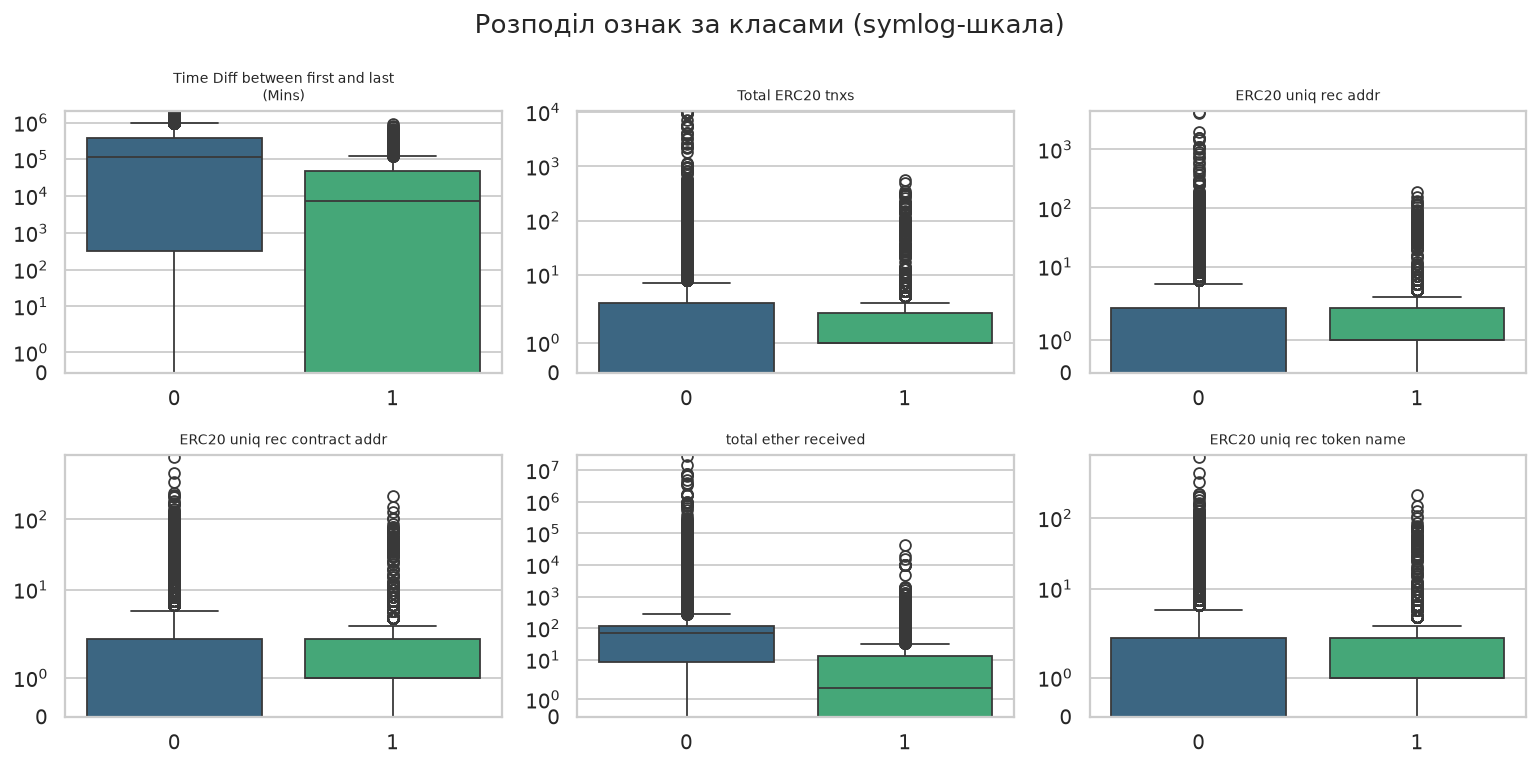

збережено assets/05-boxplots.png
Медіани за класами:
      Time Diff between first and last (Mins)  Total ERC20 tnxs  ERC20 uniq rec addr  ERC20 uniq rec contract addr  total ether received  ERC20 uniq rec token name
FLAG                                                                                                                                                               
0                                   116626.00               0.0                  0.0                           0.0                71.719                        0.0
1                                     7545.43               1.0                  1.0                           1.0                 1.679                        1.0


In [16]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for ax, c in zip(axes.ravel(), TOP[:6]):
    d = df[[c, TARGET]].copy()
    d[c] = d[c].clip(lower=0)
    sns.boxplot(data=d, x=TARGET, y=c, hue=TARGET, legend=False,
                palette="viridis", ax=ax)
    if d[c].max() > 0:
        ax.set_yscale("symlog")
        # значення невід'ємні, тож від'ємна половина symlog-осі лише
        # марнує місце й накладає підписи 10⁰ / 0 / −10⁰
        ax.set_ylim(bottom=0)
    ax.set_title(short(c), fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.suptitle("Розподіл ознак за класами (symlog-шкала)")
fig.tight_layout()
save(fig, "05-boxplots.png")

print("Медіани за класами:")
print(df.groupby(TARGET)[TOP[:6]].median().round(3).to_string())

## 4. Підготовка даних до навчання

In [17]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y)

print(f"Усього:  {len(X)} акаунтів, {X.shape[1]} ознак")
print(f"Train:   {len(X_train)} ({1 - TEST_SIZE:.0%})")
print(f"Test:    {len(X_test)} ({TEST_SIZE:.0%})")
print("\nЗбереження пропорцій класів (стратифікація):")
print(pd.DataFrame({
    "весь датасет": y.value_counts(normalize=True).sort_index().round(4),
    "train": y_train.value_counts(normalize=True).sort_index().round(4),
    "test": y_test.value_counts(normalize=True).sort_index().round(4),
}).to_string())

Усього:  9841 акаунтів, 40 ознак
Train:   7380 (75%)
Test:    2461 (25%)

Збереження пропорцій класів (стратифікація):
      весь датасет   train    test
FLAG                              
0           0.7786  0.7786  0.7785
1           0.2214  0.2214  0.2215


Підвибірка не потрібна: 9 841 рядок — це той розмір, на якому навіть SVM із
квадратичною складністю рахується за секунди, тож усі моделі навчаються на
повних даних.

### Масштабування

`StandardScaler` необхідний **kNN** і **SVM**: обидва працюють з відстанями,
а ознаки тут різняться на порядки (хвилини між транзакціями проти сум у ETH).
Деревам (`DecisionTree`, `RandomForest`, `AdaBoost`) масштабування не
потрібне — вони розбивають ознаки за порогами.

Увесь препроцесинг зібрано **всередині `Pipeline`**. Це принципово: і
медіана для заповнення пропусків, і середнє зі стандартним відхиленням для
масштабування, і список популярних токенів рахуються лише на навчальній
частині кожного фолда. Інакше статистика тесту потрапила б у навчання й
оцінка була б завищеною.

In [18]:
def make_preprocessor(num_cols=None, cat_cols=None):
    num_cols = NUM_COLS if num_cols is None else num_cols
    cat_cols = CAT_COLS if cat_cols is None else cat_cols
    return ColumnTransformer([
        ("num", Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("sc", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("imp", SimpleImputer(strategy="constant", fill_value="__missing__")),
            ("ohe", OneHotEncoder(handle_unknown="infrequent_if_exist",
                                  max_categories=11, sparse_output=False)),
        ]), cat_cols),
    ])


def make_pipe(model, num_cols=None, cat_cols=None):
    return Pipeline([("pre", make_preprocessor(num_cols, cat_cols)), ("model", model)])


_probe = make_preprocessor().fit(X_train)
print(f"Ознак після кодування: {_probe.transform(X_train).shape[1]} "
      f"({len(NUM_COLS)} числових + one-hot від {len(CAT_COLS)} категоріальних)")

Ознак після кодування: 60 (38 числових + one-hot від 2 категоріальних)


## 5. Навчання моделей

In [19]:
models = {
    "kNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(kernel="rbf", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                            random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

baseline_rows = []
for name, model in models.items():
    pipe = make_pipe(model)
    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    fit_s = time.perf_counter() - t0
    pred = pipe.predict(X_test)
    baseline_rows.append({
        "модель": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision_macro": precision_score(y_test, pred, average="macro"),
        "recall_macro": recall_score(y_test, pred, average="macro"),
        "f1_macro": f1_score(y_test, pred, average="macro"),
        "час навчання, с": round(fit_s, 2),
    })
    print(f"{name:<15} acc={baseline_rows[-1]['accuracy']:.4f}  "
          f"f1={baseline_rows[-1]['f1_macro']:.4f}  ({fit_s:.2f} с)")

baseline = pd.DataFrame(baseline_rows).sort_values("f1_macro", ascending=False)
print("\nМоделі з параметрами за замовчуванням:")
print(baseline.round(4).to_string(index=False))

kNN             acc=0.9854  f1=0.9784  (0.06 с)
Decision Tree   acc=0.9866  f1=0.9806  (0.10 с)


SVM (RBF)       acc=0.9825  f1=0.9741  (0.53 с)


Random Forest   acc=0.9919  f1=0.9881  (0.80 с)


AdaBoost        acc=0.9935  f1=0.9905  (3.00 с)

Моделі з параметрами за замовчуванням:
       модель  accuracy  precision_macro  recall_macro  f1_macro  час навчання, с
     AdaBoost    0.9935           0.9959        0.9853    0.9905             3.00
Random Forest    0.9919           0.9948        0.9817    0.9881             0.80
Decision Tree    0.9866           0.9803        0.9809    0.9806             0.10
          kNN    0.9854           0.9865        0.9709    0.9784             0.06
    SVM (RBF)    0.9825           0.9854        0.9638    0.9741             0.53


## 6. Підбір гіперпараметрів

### 6.1. kNN — пошук оптимального `n_neighbors`

  k= 1  f1=0.9777 ± 0.0023


  k= 3  f1=0.9788 ± 0.0021


  k= 5  f1=0.9793 ± 0.0032


  k= 7  f1=0.9777 ± 0.0032


  k= 9  f1=0.9786 ± 0.0032


...

  k=23  f1=0.9733 ± 0.0043


  k=25  f1=0.9732 ± 0.0045


  k=27  f1=0.9726 ± 0.0041


  k=29  f1=0.9724 ± 0.0035


  k=31  f1=0.9706 ± 0.0026

Оптимальне n_neighbors = 5


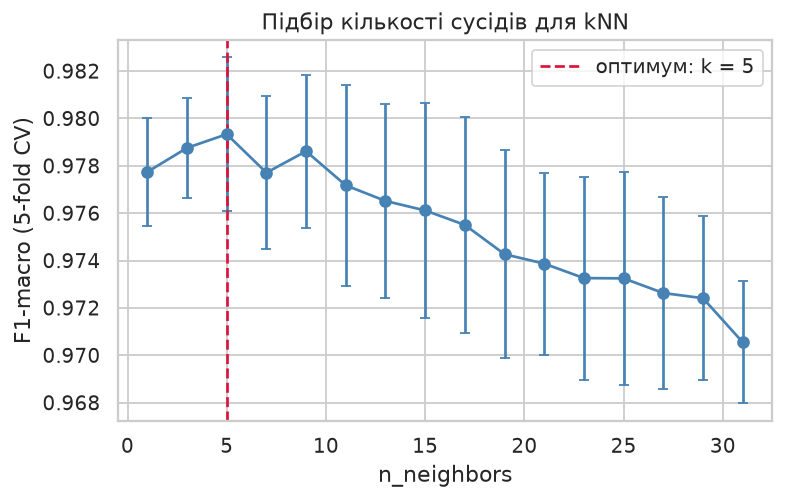

збережено assets/06-knn-sweep.png


In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
k_values = list(range(1, 32, 2))

knn_rows = []
for k in k_values:
    scores = cross_val_score(make_pipe(KNeighborsClassifier(n_neighbors=k)),
                             X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
    knn_rows.append({"n_neighbors": k, "f1_macro_cv": scores.mean(), "std": scores.std()})
    print(f"  k={k:>2}  f1={scores.mean():.4f} ± {scores.std():.4f}")

knn_sweep = pd.DataFrame(knn_rows)
best_k = int(knn_sweep.loc[knn_sweep["f1_macro_cv"].idxmax(), "n_neighbors"])
print(f"\nОптимальне n_neighbors = {best_k}")
knn_sweep.to_csv(DATA / "knn-sweep.csv", index=False)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.errorbar(knn_sweep["n_neighbors"], knn_sweep["f1_macro_cv"],
            yerr=knn_sweep["std"], marker="o", capsize=3, color="steelblue")
ax.axvline(best_k, ls="--", color="crimson", label=f"оптимум: k = {best_k}")
ax.set_xlabel("n_neighbors")
ax.set_ylabel("F1-macro (5-fold CV)")
ax.set_title("Підбір кількості сусідів для kNN")
ax.legend()
save(fig, "06-knn-sweep.png")

### 6.2. SVM — `GridSearchCV` по `C` та `gamma`

Fitting 5 folds for each of 20 candidates, totalling 100 fits



GridSearchCV: 20 комбінацій × 5 фолдів за 17.7 с
Найкращі параметри: C = 1000, gamma = 0.001
Найкращий F1-macro на CV: 0.9833


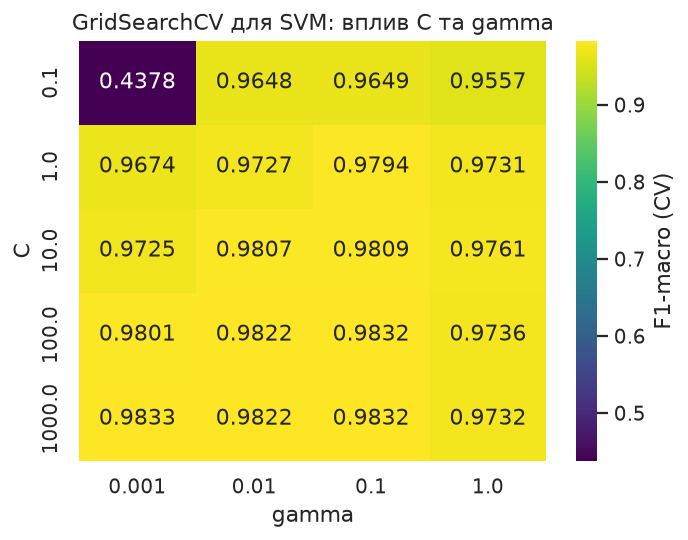

збережено assets/07-svm-grid.png


In [21]:
param_grid = {
    "model__C": [0.1, 1, 10, 100, 1000],
    "model__gamma": [0.001, 0.01, 0.1, 1],
}
grid = GridSearchCV(make_pipe(SVC(kernel="rbf", random_state=RANDOM_STATE)),
                    param_grid, cv=cv, scoring="f1_macro", n_jobs=-1, verbose=1)
t0 = time.perf_counter()
grid.fit(X_train, y_train)
print(f"\nGridSearchCV: {len(param_grid['model__C']) * len(param_grid['model__gamma'])} "
      f"комбінацій × {cv.get_n_splits()} фолдів за {time.perf_counter() - t0:.1f} с")
print(f"Найкращі параметри: C = {grid.best_params_['model__C']}, "
      f"gamma = {grid.best_params_['model__gamma']}")
print(f"Найкращий F1-macro на CV: {grid.best_score_:.4f}")

svm_grid = (pd.DataFrame(grid.cv_results_)
            [["param_model__C", "param_model__gamma", "mean_test_score", "std_test_score"]]
            .rename(columns={"param_model__C": "C", "param_model__gamma": "gamma",
                             "mean_test_score": "f1_macro_cv", "std_test_score": "std"}))
svm_grid.to_csv(DATA / "svm-grid.csv", index=False)

pivot = svm_grid.pivot(index="C", columns="gamma", values="f1_macro_cv")
fig, ax = plt.subplots(figsize=(5.8, 4.2))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="viridis",
            cbar_kws={"label": "F1-macro (CV)"}, ax=ax)
ax.set_title("GridSearchCV для SVM: вплив C та gamma")
save(fig, "07-svm-grid.png")

### 6.3. Скільки якості дає артефакт пропусків (додатково)

У підрозділі 2.3 з'ясувалося, що сама відсутність ERC20-даних ідеально
вказує на шахрая. Перевіримо, наскільки результат тримається на цьому
артефакті: порівняємо три набори ознак на однакових Random Forest.

  усі ознаки           38 числових  f1=0.9862 ± 0.0027


  без ERC20-ознак      22 числових  f1=0.9121 ± 0.0073


  лише ERC20-ознаки    16 числових  f1=0.9818 ± 0.0024


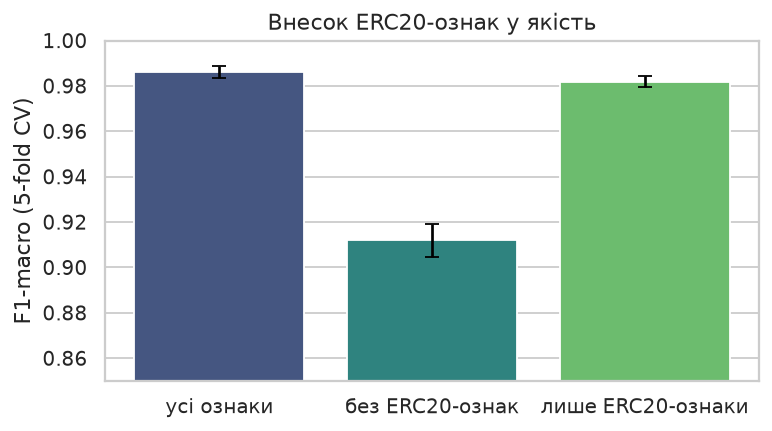

збережено assets/08-ablation.png


In [22]:
ERC_COLS = [c for c in NUM_COLS if "erc20" in c.lower()]
NON_ERC = [c for c in NUM_COLS if c not in ERC_COLS]

ablation = []
for tag, ncols, ccols in [
    ("усі ознаки", NUM_COLS, CAT_COLS),
    ("без ERC20-ознак", NON_ERC, []),
    ("лише ERC20-ознаки", ERC_COLS, CAT_COLS),
]:
    pipe = make_pipe(RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                            random_state=RANDOM_STATE), ncols, ccols)
    s = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)
    ablation.append({"набір ознак": tag, "числових": len(ncols),
                     "f1_macro_cv": s.mean(), "std": s.std()})
    print(f"  {tag:<20} {len(ncols):>2} числових  f1={s.mean():.4f} ± {s.std():.4f}")

ablation = pd.DataFrame(ablation)
ablation.to_csv(DATA / "ablation.csv", index=False)

fig, ax = plt.subplots(figsize=(6.5, 3.4))
sns.barplot(data=ablation, x="набір ознак", y="f1_macro_cv", hue="набір ознак",
            legend=False, palette="viridis", ax=ax)
ax.errorbar(range(len(ablation)), ablation["f1_macro_cv"], yerr=ablation["std"],
            fmt="none", ecolor="black", capsize=4)
ax.set_ylim(0.85, 1.0)
ax.set_xlabel("")
ax.set_ylabel("F1-macro (5-fold CV)")
ax.set_title("Внесок ERC20-ознак у якість")
save(fig, "08-ablation.png")

### 6.4. Decision Tree — вплив `max_depth` (додатково)

  depth=3              train=0.9753  cv=0.9753


  depth=5              train=0.9805  cv=0.9777


  depth=8              train=0.9939  cv=0.9845


  depth=10             train=0.9947  cv=0.9846


  depth=12             train=0.9976  cv=0.9830


  depth=15             train=0.9998  cv=0.9826


  depth=20             train=1.0000  cv=0.9832


  depth=None           train=1.0000  cv=0.9832


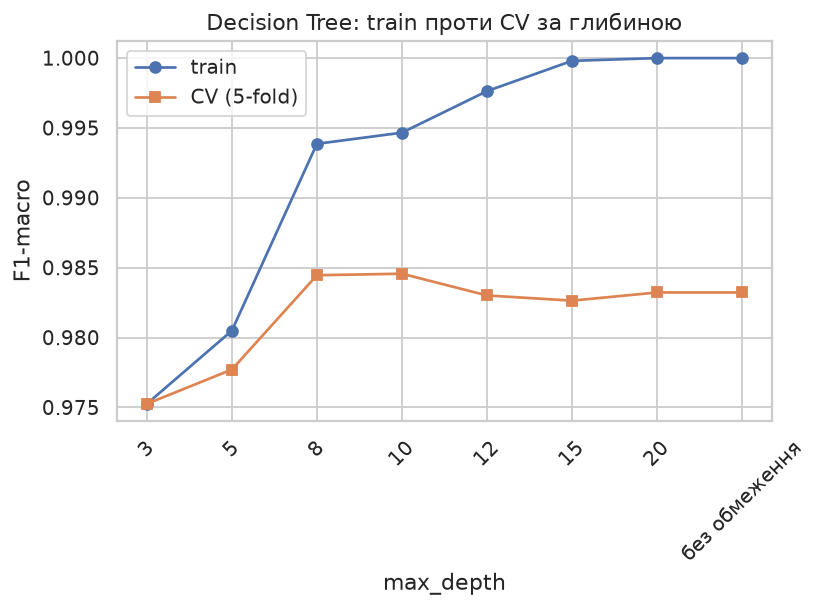

збережено assets/09-tree-depth.png


In [23]:
depths = [3, 5, 8, 10, 12, 15, 20, None]
depth_rows = []
for d in depths:
    pipe = make_pipe(DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE))
    cv_score = cross_val_score(pipe, X_train, y_train, cv=cv,
                               scoring="f1_macro", n_jobs=-1).mean()
    pipe.fit(X_train, y_train)
    train_score = f1_score(y_train, pipe.predict(X_train), average="macro")
    depth_rows.append({"max_depth": d if d else "без обмеження",
                       "f1_train": train_score, "f1_macro_cv": cv_score})
    print(f"  depth={str(d):<14} train={train_score:.4f}  cv={cv_score:.4f}")

depth_sweep = pd.DataFrame(depth_rows)
depth_sweep.to_csv(DATA / "tree-depth-sweep.csv", index=False)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
xs = range(len(depth_sweep))
ax.plot(xs, depth_sweep["f1_train"], marker="o", label="train")
ax.plot(xs, depth_sweep["f1_macro_cv"], marker="s", label="CV (5-fold)")
ax.set_xticks(list(xs))
ax.set_xticklabels(depth_sweep["max_depth"].astype(str), rotation=45)
ax.set_xlabel("max_depth")
ax.set_ylabel("F1-macro")
ax.set_title("Decision Tree: train проти CV за глибиною")
ax.legend()
save(fig, "09-tree-depth.png")

## 7. Підсумкове порівняння налаштованих моделей

In [24]:
tuned = {
    "kNN": KNeighborsClassifier(n_neighbors=best_k),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(kernel="rbf", random_state=RANDOM_STATE,
                     C=grid.best_params_["model__C"],
                     gamma=grid.best_params_["model__gamma"]),
    "Random Forest": RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                            random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

final_rows = []
final_fitted = {}
for name, model in tuned.items():
    pipe = make_pipe(model)
    t0 = time.perf_counter()
    pipe.fit(X_train, y_train)
    fit_s = time.perf_counter() - t0
    pred = pipe.predict(X_test)
    final_fitted[name] = pipe
    final_rows.append({
        "модель": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision_macro": precision_score(y_test, pred, average="macro"),
        "recall_macro": recall_score(y_test, pred, average="macro"),
        "f1_macro": f1_score(y_test, pred, average="macro"),
        "час навчання, с": round(fit_s, 2),
    })

final = pd.DataFrame(final_rows).sort_values("f1_macro", ascending=False)
print("Налаштовані моделі (тестова вибірка):")
print(final.round(4).to_string(index=False))

results = final.copy()
results["baseline_accuracy"] = round(float(y.value_counts(normalize=True).max()), 4)
results.round(4).to_csv(DATA / "results-summary.csv", index=False)
print(f"\nЗбережено {DATA / 'results-summary.csv'}")

Налаштовані моделі (тестова вибірка):
       модель  accuracy  precision_macro  recall_macro  f1_macro  час навчання, с
     AdaBoost    0.9935           0.9959        0.9853    0.9905             2.50
Random Forest    0.9919           0.9948        0.9817    0.9881             0.77
    SVM (RBF)    0.9874           0.9885        0.9748    0.9815             0.25
Decision Tree    0.9866           0.9803        0.9809    0.9806             0.10
          kNN    0.9854           0.9865        0.9709    0.9784             0.05

Збережено data/results-summary.csv


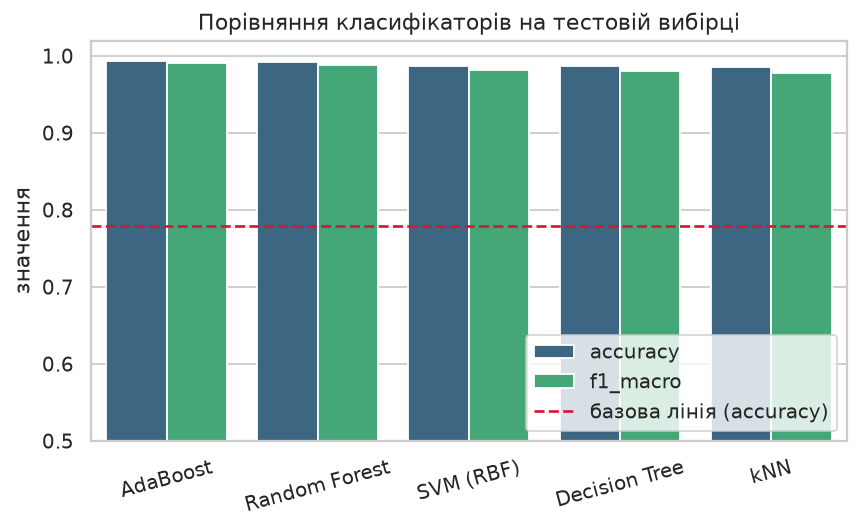

збережено assets/10-model-comparison.png


In [25]:
fig, ax = plt.subplots(figsize=(7.5, 4))
plot_df = final.melt(id_vars="модель", value_vars=["accuracy", "f1_macro"],
                     var_name="метрика", value_name="значення")
sns.barplot(data=plot_df, x="модель", y="значення", hue="метрика",
            palette="viridis", ax=ax)
ax.axhline(y.value_counts(normalize=True).max(), ls="--", color="crimson",
           label="базова лінія (accuracy)")
ax.set_ylim(0.5, 1.02)
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=15)
ax.set_title("Порівняння класифікаторів на тестовій вибірці")
ax.legend(loc="lower right")
save(fig, "10-model-comparison.png")

Найкраща модель: AdaBoost

              precision    recall  f1-score   support

  легітимний     0.9917    1.0000    0.9958      1916
 шахрайський     1.0000    0.9706    0.9851       545

    accuracy                         0.9935      2461
   macro avg     0.9959    0.9853    0.9905      2461
weighted avg     0.9936    0.9935    0.9935      2461



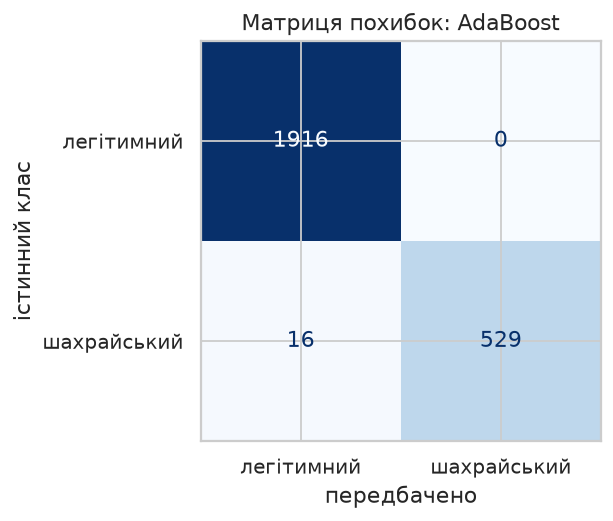

збережено assets/11-confusion-matrix.png


In [26]:
best_name = final.iloc[0]["модель"]
best_pipe = final_fitted[best_name]
best_pred = best_pipe.predict(X_test)

print(f"Найкраща модель: {best_name}\n")
print(classification_report(y_test, best_pred, digits=4,
                            target_names=["легітимний", "шахрайський"]))

fig, ax = plt.subplots(figsize=(4.6, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, best_pred),
                       display_labels=["легітимний", "шахрайський"]
                       ).plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
ax.set_title(f"Матриця похибок: {best_name}")
ax.set_xlabel("передбачено")
ax.set_ylabel("істинний клас")
save(fig, "11-confusion-matrix.png")

In [27]:
print("Файли результатів:")
for f in sorted(DATA.glob("*.csv")):
    print("  ", f)
print("Рисунки:")
for f in sorted(ASSETS.glob("*.png")):
    print("  ", f)

Файли результатів:
   data/ablation.csv
   data/ethereum-fraud.csv
   data/knn-sweep.csv
   data/results-summary.csv
   data/svm-grid.csv
   data/tree-depth-sweep.csv
Рисунки:
   assets/01-class-distribution.png
   assets/02-feature-importance.png
   assets/03-correlation-heatmap.png
   assets/04-histograms.png
   assets/05-boxplots.png
   assets/06-knn-sweep.png
   assets/07-svm-grid.png
   assets/08-ablation.png
   assets/09-tree-depth.png
   assets/10-model-comparison.png
   assets/11-confusion-matrix.png
